In [1]:
import nilearn 
from nilearn import datasets, plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from scipy.stats import spearmanr
from scipy import stats
import os.path as op 
import pickle
import tol_colors as tc
import seaborn as sns

In [2]:
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100) 

[fetch_atlas_schaefer_2018] Dataset found in /global/homes/m/mphagen/nilearn_data/schaefer_2018


In [3]:
#downloaded from https://github.com/ThomasYeoLab/CBIG/blob/master/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Centroid_coordinates/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.Centroid_RAS.csv
centroid_df = pd.read_csv('/global/homes/m/mphagen/functional-connectivity/connectome-comparison/scripts/notebooks/exploratory/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.Centroid_RAS.csv') 

In [4]:
coords = plotting.find_parcellation_cut_coords(labels_img=schaefer['maps'])


In [5]:
coords[99]

array([  7.03716919, -52.45658638,  30.40544157])

In [6]:
centroid_df

,ROI Label,ROI Name,R,A,S
0,1,7Networks_LH_Vis_1,-26,-34,-17
1,2,7Networks_LH_Vis_2,-26,-77,-14
2,3,7Networks_LH_Vis_3,-17,-60,-7
3,4,7Networks_LH_Vis_4,-27,-95,-4
4,5,7Networks_LH_Vis_5,-5,-92,-2
...,...,...,...,...,...
95,96,7Networks_RH_Default_PFCdPFCm_1,7,48,1
96,97,7Networks_RH_Default_PFCdPFCm_2,11,50,39
97,98,7Networks_RH_Default_PFCdPFCm_3,26,24,50
98,99,7Networks_RH_Default_pCunPCC_1,12,-54,14


In [7]:
#use wokyconn https://github.com/HALFpipe/wonkyconn/blob/main/wonkyconn/features/distance_dependence.py
#for distance dependence

In [8]:
data_path = '/global/homes/m/mphagen/functional-connectivity/connectome-comparison/scripts/notebooks/02-Analysis/results'

In [9]:
import datetime

In [13]:
with open(f'/global/homes/m/mphagen/functional-connectivity/connectome-comparison/scripts/notebooks/02-Analysis/results/2026-06-02_qcfc_dict.pkl', 'rb') as file: 
   qcfc_dict= pickle.load( file) 

In [14]:
dist_mat = euclidean_distances(np.array(centroid_df.loc[:, ['R', 'A', 'S']])) 

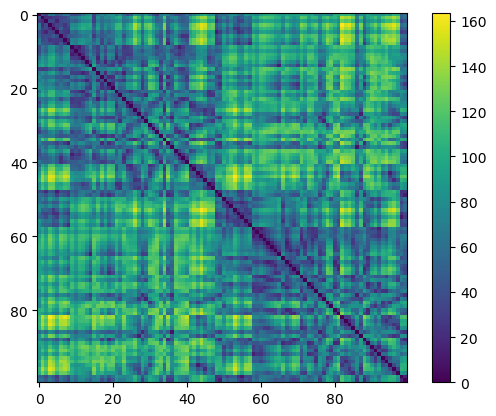

In [15]:
plt.imshow(dist_mat) 
plt.colorbar()

In [16]:
qcfc_dict.keys() 

dict_keys(['lassoBIC_MSMAll_FIX_ses-1', 'lassoBIC_MSMAll_FIX_ses-2', '-correlation_MSMAll_FIX_ses-1', '-correlation_MSMAll_FIX_ses-2', 'lassoBIC_xcpd_ses-1', 'lassoBIC_xcpd_ses-2', 'ridgeCV_MSMAll_FIX_ses-1', 'ridgeCV_MSMAll_FIX_ses-2', 'partial_MSMAll_FIX_ses-1', 'partial_MSMAll_FIX_ses-2', 'uoi_MSMAll_FIX_ses-1', 'uoi_MSMAll_FIX_ses-2'])

In [17]:
mask = np.triu(np.ones_like(np.ones((100,100)), dtype=bool), k=1) 

In [18]:
np.array(qcfc_dict['-correlation_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100)[mask]

array([ 0.22702449,  0.1531474 ,  0.22399186, ..., -0.01963637,
       -0.0425244 ,  0.06475466], shape=(4950,))

In [19]:
import textwrap
def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)

from matplotlib.colors import to_rgb
def whiten(color, factor):
    return np.array(to_rgb(color)) * factor + (1 - factor)

cm =  sns.color_palette(tc.muted)
cm.pop(2) 

models = ['Pearson', 'Ridge', 'PCorr', 'LASSO', 'UoI', 'Pearson_Reg', 'PNC' ]
pipelines = ['MinProc', 'XCPD']
labels = models + pipelines
palette_colors = cm
palette_dict = {labels: whiten(color, .8) for labels, color in zip(labels, palette_colors)}
models.remove('Pearson')

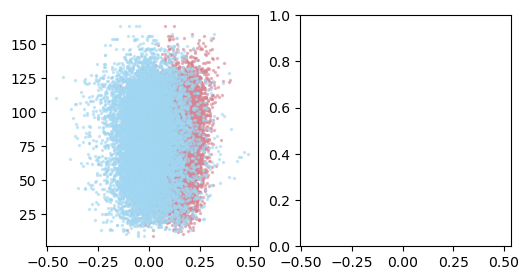

In [20]:
fig, axes = plt.subplots(1,2, figsize=(6, 3), sharex=True)

axes[0].scatter(np.array(qcfc_dict['-correlation_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100)[mask].ravel(), dist_mat[mask].ravel(), s=2, color=palette_dict['Pearson'], alpha=.5)
# axes[0].scatter(np.array(qcfc_dict['-correlation_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100)[mask].ravel(), dist_mat[mask].ravel(),s=5, alpha=.9)

axes[0].scatter(np.array(qcfc_dict['lassoBIC_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100).ravel(), dist_mat.ravel(), s=2,color=palette_dict['LASSO'], alpha=.5)
# axes[1].scatter(np.array(qcfc_dict['lassoBIC_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100).ravel(), dist_mat.ravel(),s=5, alpha=.9)



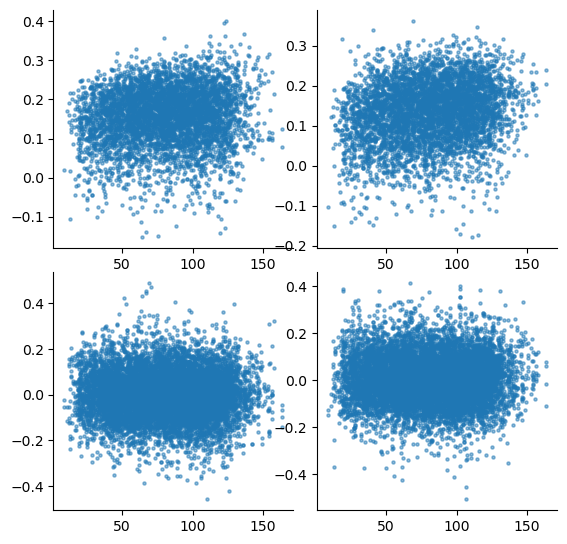

In [21]:
fig, axes = plt.subplots(2,2, figsize=(6.5,6.5)) 

axes[0,0].scatter(dist_mat[mask].ravel(),np.array(qcfc_dict['-correlation_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100)[mask].ravel(),  s=5, alpha=.5, ) 
axes[0,1].scatter(dist_mat[mask].ravel(), np.array(qcfc_dict['-correlation_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100)[mask].ravel(), s=5, alpha=.5)

# axes[0].set_xlim(-.5, .5) 
fig.subplots_adjust(wspace=.1, hspace=.1)



axes[1,0].scatter(dist_mat.ravel(), np.array(qcfc_dict['lassoBIC_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100).ravel(), s=5, alpha=.5)
axes[1,1].scatter(dist_mat.ravel(), np.array(qcfc_dict['lassoBIC_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100).ravel(), s=5, alpha=.5)

# axes[0].set_xlim(-.5, .5) 
sns.despine()

In [22]:
qcfc_dict.keys() 

dict_keys(['lassoBIC_MSMAll_FIX_ses-1', 'lassoBIC_MSMAll_FIX_ses-2', '-correlation_MSMAll_FIX_ses-1', '-correlation_MSMAll_FIX_ses-2', 'lassoBIC_xcpd_ses-1', 'lassoBIC_xcpd_ses-2', 'ridgeCV_MSMAll_FIX_ses-1', 'ridgeCV_MSMAll_FIX_ses-2', 'partial_MSMAll_FIX_ses-1', 'partial_MSMAll_FIX_ses-2', 'uoi_MSMAll_FIX_ses-1', 'uoi_MSMAll_FIX_ses-2'])

/tmp/ipykernel_1924727/2631982787.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels( labels=['', '', '', 0, '', '', '' ])
/tmp/ipykernel_1924727/2631982787.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_yticklabels( labels=['', '', '', 0, '', '', '' ])
/tmp/ipykernel_1924727/2631982787.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[3].set_yticklabels( labels=['', '', '', 0, '', '', '' ])
/tmp/ipykernel_1924727/2631982787.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[4].set_yticklabels( labels=['', '', '', 0, '', '', '' ])


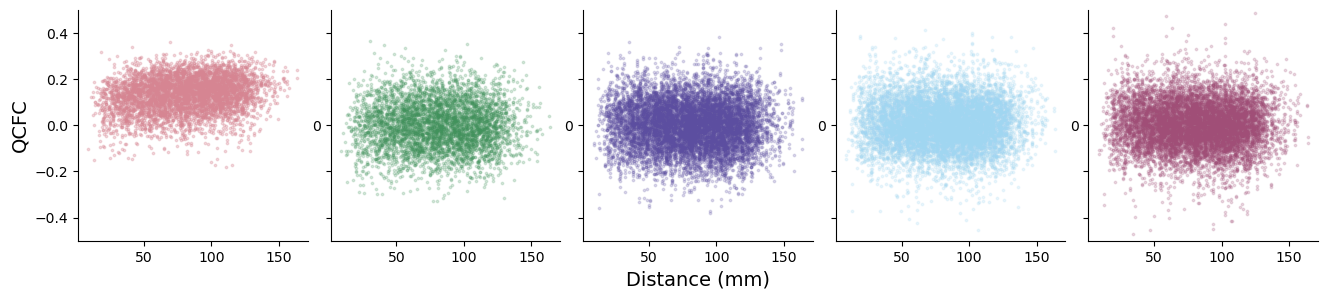

In [26]:
fig, axes = plt.subplots(1,5, figsize=(16,3), sharey=False, sharex=True) 

# axes[0].scatter(dist_mat[mask].ravel(),np.array(qcfc_dict['-correlation_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100)[mask].ravel(),  s=5, alpha=.5, color=palette_dict['Pearson']) 
axes[0].scatter(dist_mat[mask].ravel(), np.array(qcfc_dict['-correlation_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100)[mask].ravel(), s=3, alpha=.3, color=palette_dict['Pearson'])

axes[2].set_xlabel('Distance (mm)', fontsize=14)
axes[0].set_ylabel('QCFC', fontsize=14)
# axes[0].set_xlim(-.5, .5) 

# axes[0].axhline(0, color='grey', linestyle='--', alpha=.5) 
# axes[1].axhline(0, color='grey', linestyle='--', alpha=.5) 
# axes[2].axhline(0, color='grey', linestyle='--', alpha=.5) 
# axes[3].axhline(0, color='grey', linestyle='--', alpha=.5) 
# axes[4].axhline(0, color='grey', linestyle='--', alpha=.5) 
# axes[0].set_title(f'Pearson (r={round(pearson_ses_1, 3)} )')
# axes[1].set_title(f'Partial (r={round(partial_ses_1, 3)} )')
# axes[2].set_title(f'Ridge (r={round(ridge_ses_1, 3)} )')
# axes[3].set_title(f'LASSO (r={round(lasso_ses_1, 3)} )')
# axes[4].set_title(f'UoI (r={round(uoi_ses_1, 3)} )')


fig.subplots_adjust(wspace=.1, hspace=.1)
# axes[1].scatter(dist_mat[mask].ravel(),np.array(qcfc_dict['partial_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100)[mask].ravel(),  s=5, alpha=.5, color=palette_dict['PCorr']) 
axes[1].scatter(dist_mat[mask].ravel(), np.array(qcfc_dict['partial_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100)[mask].ravel(), s=3, alpha=.2, color=palette_dict['PCorr'])
axes[1].set_yticklabels( labels=['', '', '', 0, '', '', '' ]) 
axes[2].set_yticklabels( labels=['', '', '', 0, '', '', '' ]) 
axes[3].set_yticklabels( labels=['', '', '', 0, '', '', '' ]) 
axes[4].set_yticklabels( labels=['', '', '', 0, '', '', '' ]) 


# axes[2].scatter(dist_mat.ravel(), np.array(qcfc_dict['ridgeCV_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100).ravel(), s=5, alpha=.5, color=palette_dict['Ridge']) 
axes[2].scatter(dist_mat.ravel(), np.array(qcfc_dict['ridgeCV_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100).ravel(), s=3, alpha=.2, color=palette_dict['Ridge']) 


# axes[3].scatter(dist_mat.ravel(), np.array(qcfc_dict['lassoBIC_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100).ravel(), s=5, alpha=.5, color=palette_dict['LASSO']) 
axes[3].scatter(dist_mat.ravel(), np.array(qcfc_dict['lassoBIC_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100).ravel(), s=3, alpha=.2, color=palette_dict['LASSO']) 

# axes[4].scatter(dist_mat.ravel(), np.array(qcfc_dict['uoi_MSMAll_FIX_ses-2']['r'], dtype=float).reshape(100,100).ravel(), s=5, alpha=.5, color=palette_dict['UoI']) 
axes[4].scatter(dist_mat.ravel(), np.array(qcfc_dict['uoi_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100).ravel(), s=3, alpha=.2, color=palette_dict['UoI']) 

axes[0].set_ylim(-.5, .5) 
axes[1].set_ylim(-.5, .5) 
axes[2].set_ylim(-.5, .5) 

axes[3].set_ylim(-.5, .5) 
axes[4].set_ylim(-.5, .5) 


sns.despine()

plt.savefig('dd_qcfc.png', bbox_inches='tight') 

In [ ]:
pearson_ses_1 = pd.DataFrame([np.array(qcfc_dict['-correlation_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100)[mask].ravel(),
             dist_mat[mask].ravel()]).T.corr()[0][1]

In [ ]:
partial_ses_1 = pd.DataFrame([np.array(qcfc_dict['partial_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100)[mask].ravel(),
             dist_mat[mask].ravel()]).T.corr()[0][1]

In [ ]:
lasso_ses_1 = pd.DataFrame([np.array(qcfc_dict['lassoBIC_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100).ravel(),
             dist_mat.ravel()]).T.corr()[0][1]

In [ ]:
ridge_ses_1 = pd.DataFrame([np.array(qcfc_dict['ridgeCV_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100).ravel(),
             dist_mat.ravel()]).T.corr()[0][1]

In [ ]:
uoi_ses_1 = pd.DataFrame([np.array(qcfc_dict['uoi_MSMAll_FIX_ses-1']['r'], dtype=float).reshape(100,100).ravel(),
             dist_mat.ravel()]).T.corr()[0][1]